In [1]:
import xarray as xr
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from nc_processing import calc_spatial_mean

def get_time_slice_mean(ds, timeperiod=['2050', '2069']):
    time_slice = ds.sel(time=slice(timeperiod[0], timeperiod[1]))
    mean_values = time_slice.mean(dim='time')
    return mean_values


from HiLLA_utils import get_ds, spatial_mean, set_time_to_center_of_bounds, yearly_timeseries

# get standard variable names, settings for plotting, region bounds etc. 
from config import models, regions, HiLLA_altitudes, path_archive, ens_mems_arise_UK, ens_mems_CE, colours, model_colors, model_names, lat_band_dict, UKESM_ARISE_run_IDs, UKESM_ARISE_run_dict, CESM_ARISE_run_IDs

lss = {'13km':'solid', '15km':'dashdot'}


In [2]:
## inputs

CESM_mass_flux_correction = 96.0576/115.10734 # personal communication from Dan V (16th June 2025)

# "mass is calculated considering a ternary compound with ammonia, because that’s how nucleation works, but then this is not corrected 
# ... when considering the final partitioning of mass into sulfate. It wasn’t fixed in MAM4, but is now in MAM5"


In [3]:

path_CESM_deposition = path_archive+'CESM_data/Deposition/'

file_list = [path_CESM_deposition+f for f in os.listdir(path_CESM_deposition) if '.nc' in f]

files_case01 = [f for f in file_list if 'case01' in f]
files_case04 = [f for f in file_list if 'case04' in f]


vars = ['so4_a1DDF', 'so4_a2DDF', 'so4_a3DDF',
        'so4_c1DDF', 'so4_c2DDF', 'so4_c3DDF',
        'so4_a1SFWET', 'so4_a2SFWET', 'so4_a3SFWET', 
        'so4_c1SFWET', 'so4_c2SFWET', 'so4_c3SFWET', 
        ]

# case01
ds_list = []
for f in files_case01:
    ds = xr.open_dataset(f)
    ds_list.append(ds)
ds_case01 = xr.merge(ds_list)[vars]
ds_case01['DDF'] = CESM_mass_flux_correction*(ds_case01['so4_a1DDF'] + ds_case01['so4_a2DDF'] + ds_case01['so4_a3DDF'] + ds_case01['so4_c1DDF'] + ds_case01['so4_c2DDF'] + ds_case01['so4_c3DDF'])
ds_case01['SFWET'] = CESM_mass_flux_correction*-1*(ds_case01['so4_a1SFWET'] + ds_case01['so4_a2SFWET'] + ds_case01['so4_a3SFWET'] + ds_case01['so4_c1SFWET'] + ds_case01['so4_c2SFWET'] + ds_case01['so4_c3SFWET'])

# case04
ds_list = []
for f in files_case04:
    ds = xr.open_dataset(f)
    ds_list.append(ds)
ds_case04 = xr.merge(ds_list)[vars]
ds_case04['DDF'] = CESM_mass_flux_correction*(ds_case04['so4_a1DDF'] + ds_case04['so4_a2DDF'] + ds_case04['so4_a3DDF'] + ds_case04['so4_c1DDF'] + ds_case04['so4_c2DDF'] + ds_case04['so4_c3DDF'])
ds_case04['SFWET'] = CESM_mass_flux_correction*-1*(ds_case04['so4_a1SFWET'] + ds_case04['so4_a2SFWET'] + ds_case04['so4_a3SFWET'] + ds_case04['so4_c1SFWET'] + ds_case04['so4_c2SFWET'] + ds_case04['so4_c3SFWET'])

In [4]:
unit_conversion = 1000*365*24*60*60*0.333798 # kg.SO4/m2/s to grams.S/m2/year

ds_case01_mean = get_time_slice_mean(ds_case01)*unit_conversion
ds_case04_mean = get_time_slice_mean(ds_case04)*unit_conversion

### get background in same format:

ds_ssp245_background_dry_CE = CESM_mass_flux_correction*unit_conversion*get_time_slice_mean(xr.open_mfdataset('../../Extra_data/CESM2-WACCM_SSP245/dryso4/*.nc'), timeperiod=['2050', '2069'])
ds_ssp245_background_wet_CE = CESM_mass_flux_correction*-1*unit_conversion*get_time_slice_mean(xr.open_mfdataset('../../Extra_data/CESM2-WACCM_SSP245/wetso4/*.nc'), timeperiod=['2050', '2069'])
ds_ssp245_CE = (ds_ssp245_background_dry_CE['dryso4'] + ds_ssp245_background_wet_CE['wetso4']).to_dataset(name='so4')

ds_ssp245_background_dry_PD_CE = CESM_mass_flux_correction*unit_conversion*get_time_slice_mean(xr.open_mfdataset('../../Extra_data/CESM2-WACCM_SSP245/dryso4/*.nc'), timeperiod=['2020', '2029'])
ds_ssp245_background_wet_PD_CE = CESM_mass_flux_correction*-1*unit_conversion*get_time_slice_mean(xr.open_mfdataset('../../Extra_data/CESM2-WACCM_SSP245/wetso4/*.nc'), timeperiod=['2020', '2029'])
ds_ssp245_PD_CE = (ds_ssp245_background_dry_PD_CE['dryso4'] + ds_ssp245_background_wet_PD_CE['wetso4']).to_dataset(name='so4')


### checksum 
HiLLA_13_total_delta_dep_CE = (ds_case01_mean['DDF'] - ds_ssp245_background_dry_CE['dryso4']) + (ds_case01_mean['SFWET'] - ds_ssp245_background_wet_CE['wetso4'])
HiLLA_15_total_delta_dep_CE = (ds_case04_mean['DDF'] - ds_ssp245_background_dry_CE['dryso4']) + (ds_case04_mean['SFWET'] - ds_ssp245_background_wet_CE['wetso4'])

areacella_cesm = xr.open_dataset('/badc/cmip6/data/CMIP6/CMIP/NCAR/CESM2-WACCM/historical/r1i1p1f1/fx/areacella/gn/latest/areacella_fx_CESM2-WACCM_historical_r1i1p1f1_gn.nc')
HiLLA_13_total_delta_dep_sum_CE = ((HiLLA_13_total_delta_dep_CE)*areacella_cesm.areacella).sum()
HiLLA_15_total_delta_dep_sum_CE = ((HiLLA_15_total_delta_dep_CE)*areacella_cesm.areacella).sum()

print(HiLLA_13_total_delta_dep_sum_CE.values.item()/(1E12))
print(HiLLA_15_total_delta_dep_sum_CE.values.item()/(1E12))
## these are Tg S units, we inject 6Tg S (12TG SO2) 

/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'dryso4' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'dryso4' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'wetso4' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/users/a_duffey/.conda/envs/main2/lib/python3.12/site-packages/xarray/conventions.py:286: SerializationWarning: variable 'wetso4' has multiple fill values {1e+20, 1e+20} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/hom

6.041874989056
6.024915320832


In [5]:
### repeat, now reading in UKESM data: 

seconds_per_year = 365*24*60*60
unit_conversion_UKESM = 32.07*seconds_per_year # moles per grid box per second to grams per grid box per year
unit_conversion_cmor = 1000*365*24*60*60*0.333798 # kg.SO4/m2/s to grams.S/m2/year

def wet_dry_dep_UK(run):
    print(run)
    #path_archive = '/gws/nopw/j04/cpom/aduffey/pp_archive_hills/'
    path = path_archive + run + '/AERmon/'
    ## note dry deposition only non-zero for bottom level
    
    variables_dry = ['dry_dep_accum',
                 'dry_dep_aitken',
                 'dry_dep_coarse',
                 'dry_dep_nucl',]
    
    ds_list = []
    for var in variables_dry:
        ds = xr.open_mfdataset(path + '{}/*.nc'.format(var)).isel(atmosphere_hybrid_height_coordinate_1=0)
        ds_list.append(ds)
    
    dry_deposition_ds = xr.merge(ds_list)
    dry_deposition_ds['drydep_H2SO4'] = dry_deposition_ds['dry_dep_accum'] + dry_deposition_ds['dry_dep_aitken'] + dry_deposition_ds['dry_dep_coarse'] + dry_deposition_ds['dry_dep_nucl']
    
    #  we sum over whole column for the impact and nucleation scavenging
    variables_wet =  ['imp_scav_accum',
                      'imp_scav_aitken',
                      'imp_scav_coarse',
                      'imp_scav_nucl',
                      'nuc_scav_accum',
                      'nuc_scav_aitken',
                      'nuc_scav_coarse']
    
    plume_scavenging_vars = ['plum_scav_ait_sol',
                              'plum_scav_acc_sol',
                              'plum_scav_corr_sol']
    
    ds_list = []
    for var in variables_wet:
        print(var)
        ds = xr.open_mfdataset(path + '{}/*.nc'.format(var)).sum('atmosphere_hybrid_height_coordinate_1')
        ds_list.append(ds)
    
    for var in plume_scavenging_vars:
        print(var)
        ds = xr.open_mfdataset(path + '{}/*.nc'.format(var))
        ds_list.append(ds)
        
    wet_deposition_ds = xr.merge(ds_list)
    wet_deposition_ds['wetdep_H2SO4'] = wet_deposition_ds['imp_scav_accum'] + wet_deposition_ds['imp_scav_aitken'] +  wet_deposition_ds['imp_scav_coarse'] +  wet_deposition_ds['imp_scav_nucl'] +  wet_deposition_ds['nuc_scav_accum'] + wet_deposition_ds['nuc_scav_aitken'] + wet_deposition_ds['nuc_scav_coarse'] + wet_deposition_ds['plum_scav_ait_sol'] + wet_deposition_ds['plum_scav_acc_sol'] + wet_deposition_ds['plum_scav_corr_sol']
    
    
    wet_dep_mean = get_time_slice_mean(wet_deposition_ds).load()*unit_conversion_UKESM
    dry_dep_mean = get_time_slice_mean(dry_deposition_ds).load()*unit_conversion_UKESM

    return wet_dep_mean, dry_dep_mean

## get UKESM grid cell areas:
areacella_ukesm = xr.open_dataset('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/piControl/r1i1p1f2/fx/areacella/gn/latest/areacella_fx_UKESM1-0-LL_piControl_r1i1p1f2_gn.nc')

wet_dep_ds_13_UK, dry_dep_ds_13_UK = wet_dry_dep_UK('u-dm204dn587')
wet_dep_ds_15_UK, dry_dep_ds_15_UK = wet_dry_dep_UK('u-dn760')

wet_dep_ds_13_UK, dry_dep_ds_13_UK = wet_dep_ds_13_UK.rename({'latitude':'lat', 'longitude':'lon'}), dry_dep_ds_13_UK.rename({'latitude':'lat', 'longitude':'lon'})
wet_dep_ds_15_UK, dry_dep_ds_15_UK = wet_dep_ds_15_UK.rename({'latitude':'lat', 'longitude':'lon'}), dry_dep_ds_15_UK.rename({'latitude':'lat', 'longitude':'lon'})

u-dm204dn587
imp_scav_accum
imp_scav_aitken
imp_scav_coarse
imp_scav_nucl
nuc_scav_accum
nuc_scav_aitken
nuc_scav_coarse
plum_scav_ait_sol
plum_scav_acc_sol
plum_scav_corr_sol
u-dn760
imp_scav_accum
imp_scav_aitken
imp_scav_coarse
imp_scav_nucl
nuc_scav_accum
nuc_scav_aitken
nuc_scav_coarse
plum_scav_ait_sol
plum_scav_acc_sol
plum_scav_corr_sol


In [6]:
ds_hist_background_dry_UK = unit_conversion_cmor*get_time_slice_mean(xr.open_mfdataset('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/AERmon/dryso4/gn/latest/*.nc'), timeperiod=['1970', '1990'])
ds_hist_background_wet_UK = unit_conversion_cmor*get_time_slice_mean(xr.open_mfdataset('/badc/cmip6/data/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/AERmon/wetso4/gn/latest/*.nc'), timeperiod=['1970', '1990'])
ds_hist_UK = (ds_hist_background_dry_UK['dryso4'] + ds_hist_background_wet_UK['wetso4']).to_dataset(name='so4')


In [7]:
## also get the ssp245 background 

ds_ssp245_background_dry_UK = unit_conversion_cmor*get_time_slice_mean(xr.open_mfdataset('/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/dryso4/gn/latest/*.nc'), timeperiod=['2050', '2069'])
ds_ssp245_background_wet_UK = unit_conversion_cmor*get_time_slice_mean(xr.open_mfdataset('/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/wetso4/gn/latest/*.nc'), timeperiod=['2050', '2069'])
ds_ssp245_UK = (ds_ssp245_background_dry_UK['dryso4'] + ds_ssp245_background_wet_UK['wetso4']).to_dataset(name='so4')

ds_ssp245_background_dry_PD_UK = unit_conversion_cmor*get_time_slice_mean(xr.open_mfdataset('/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/dryso4/gn/latest/*.nc'), timeperiod=['2020', '2029'])
ds_ssp245_background_wet_PD_UK = unit_conversion_cmor*get_time_slice_mean(xr.open_mfdataset('/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/wetso4/gn/latest/*.nc'), timeperiod=['2020', '2029'])
ds_ssp245_PD_UK = (ds_ssp245_background_dry_PD_UK['dryso4'] + ds_ssp245_background_wet_PD_UK['wetso4']).to_dataset(name='so4')


### checksum 
HiLLA_13_total_delta_dep_UK = (wet_dep_ds_13_UK['wetdep_H2SO4']/areacella_ukesm.areacella - ds_ssp245_background_wet_UK['wetso4']) + (dry_dep_ds_13_UK['drydep_H2SO4']/areacella_ukesm.areacella - ds_ssp245_background_dry_UK['dryso4'])
HiLLA_15_total_delta_dep_UK = (wet_dep_ds_15_UK['wetdep_H2SO4']/areacella_ukesm.areacella - ds_ssp245_background_wet_UK['wetso4']) + (dry_dep_ds_15_UK['drydep_H2SO4']/areacella_ukesm.areacella - ds_ssp245_background_dry_UK['dryso4'])

HiLLA_13_total_delta_dep_sum_UK = ((HiLLA_13_total_delta_dep_UK)*areacella_ukesm.areacella).sum()
HiLLA_15_total_delta_dep_sum_UK = ((HiLLA_15_total_delta_dep_UK)*areacella_ukesm.areacella).sum()

print(HiLLA_13_total_delta_dep_sum_UK.values.item()/(1E12))
print(HiLLA_15_total_delta_dep_sum_UK.values.item()/(1E12))
## these are Tg S units, we inject 6Tg S (12TG SO2) 

# note that UKESM sees less than the expected total deposition, both for HiLLA (~70% of injected S) and the cmor-ized ARISE outputs (~85%)

4.454676430848
4.31094366208


In [8]:
# plus get arise deposition:

### CESM
## deposition
arise_dep = get_time_slice_mean(xr.open_mfdataset('/home/users/a_duffey/UKESM_runs_analysis/HiLLA-SAI/Extra_data/CESM2-WACCM_ARISE/Deposition/*.nc'))[vars]

arise_dep['DDF'] = unit_conversion*CESM_mass_flux_correction*(arise_dep['so4_a1DDF'] + arise_dep['so4_a2DDF'] + arise_dep['so4_a3DDF'] + arise_dep['so4_c1DDF'] + arise_dep['so4_c2DDF'] + arise_dep['so4_c3DDF'])
arise_dep['SFWET'] = unit_conversion*CESM_mass_flux_correction*(-1)*(arise_dep['so4_a1SFWET'] + arise_dep['so4_a2SFWET'] + arise_dep['so4_a3SFWET'] + arise_dep['so4_c1SFWET'] + arise_dep['so4_c2SFWET'] + arise_dep['so4_c3SFWET'])
arise_dep['Total_deposition'] = arise_dep['DDF'] + arise_dep['SFWET']

arise_total_delta_dep_CE = ((arise_dep['DDF'] - ds_ssp245_background_dry_CE['dryso4']) + (arise_dep['SFWET'] - ds_ssp245_background_wet_CE['wetso4'])).to_dataset(name='so4')


## cooling
arise_cooling_CE = -1*xr.open_dataset('../intermediate_outputs/cooling_annual/CESM_ARISE_cooling.nc').sel(time=slice('2050', '2069')).mean('time').rename({'latitude':'lat', 'longitude':'lon'})
arise_cooling_gm_CE = calc_spatial_mean(arise_cooling_CE.tas, lon_name="lon", lat_name="lat")


### UKESM

## deposition
ds_arise_dryso4_UK = unit_conversion_cmor*xr.open_mfdataset('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/r1i1p1f2/AERmon/dryso4/gn/v20220325/*.nc')
ds_arise_wetso4_UK = unit_conversion_cmor*xr.open_mfdataset('/badc/deposited2022/arise/data/ARISE/MOHC/UKESM1-0-LL/arise-sai-1p5/r1i1p1f2/AERmon/wetso4/gn/v20220325/*.nc')
arise_total_delta_dep_UK =  get_time_slice_mean((ds_arise_dryso4_UK['dryso4'] + ds_arise_wetso4_UK['wetso4']).to_dataset(name='so4')) - ds_ssp245_UK

arise_cooling_UK = -1*xr.open_dataset('../intermediate_outputs/cooling_annual/UKESM_ARISE_cooling.nc').sel(time=slice('2050', '2069')).mean('time').rename({'latitude':'lat', 'longitude':'lon'})
arise_cooling_gm_UK = calc_spatial_mean(arise_cooling_UK.tas, lon_name="lon", lat_name="lat")


In [9]:
"""
unit_conversion_so2 = 1000*365*24*60*60*(32.065/(32.065+2*15.999)) # kg.SO2/m2/s to grams.S/m2/year

ds_ssp245_background_dryso2_CE = unit_conversion_so2*get_time_slice_mean(xr.open_mfdataset('../../Extra_data/CESM2-WACCM_SSP245/dryso2/*.nc'))
ds_ssp245_background_wetso2_CE = unit_conversion_so2*get_time_slice_mean(xr.open_mfdataset('../../Extra_data/CESM2-WACCM_SSP245/wetso2/*.nc'))

ds_so2_ssp245_CE = (ds_ssp245_background_dryso2_CE['dryso2'] + ds_ssp245_background_wetso2_CE['wetso2']).to_dataset(name='so2')

ds_ssp245_background_dryso2_UK = unit_conversion_cmor*get_time_slice_mean(xr.open_mfdataset('/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/dryso2/gn/latest/*.nc')).rename({'lat':'latitude', 'lon':'longitude'})
ds_ssp245_background_wetso2_UK = unit_conversion_cmor*get_time_slice_mean(xr.open_mfdataset('/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/wetso2/gn/latest/*.nc')).rename({'lat':'latitude', 'lon':'longitude'})
ds_so2_ssp245_UK = (ds_ssp245_background_dryso2_UK['dryso2'] + ds_ssp245_background_wetso2_UK['wetso2']).to_dataset(name='so2')

print((ds_ssp245_CE['so4']*areacella_cesm.areacella).sum().values/(1E12))

so4, so2 = (ds_ssp245_UK['so4']*areacella_ukesm.areacella).sum().values/(1E12), (ds_so2_ssp245_UK['so2']*areacella_ukesm.areacella).sum().values/(1E12)
print(so4)
print(so2)
print(so4 + so2)
"""

"\nunit_conversion_so2 = 1000*365*24*60*60*(32.065/(32.065+2*15.999)) # kg.SO2/m2/s to grams.S/m2/year\n\nds_ssp245_background_dryso2_CE = unit_conversion_so2*get_time_slice_mean(xr.open_mfdataset('../../Extra_data/CESM2-WACCM_SSP245/dryso2/*.nc'))\nds_ssp245_background_wetso2_CE = unit_conversion_so2*get_time_slice_mean(xr.open_mfdataset('../../Extra_data/CESM2-WACCM_SSP245/wetso2/*.nc'))\n\nds_so2_ssp245_CE = (ds_ssp245_background_dryso2_CE['dryso2'] + ds_ssp245_background_wetso2_CE['wetso2']).to_dataset(name='so2')\n\nds_ssp245_background_dryso2_UK = unit_conversion_cmor*get_time_slice_mean(xr.open_mfdataset('/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/dryso2/gn/latest/*.nc')).rename({'lat':'latitude', 'lon':'longitude'})\nds_ssp245_background_wetso2_UK = unit_conversion_cmor*get_time_slice_mean(xr.open_mfdataset('/badc/cmip6/data/CMIP6/ScenarioMIP/MOHC/UKESM1-0-LL/ssp245/r1i1p1f2/AERmon/wetso2/gn/latest/*.nc')).rename({'lat':'latitude', 'lon':'longitu

In [10]:
### also get the HiLLA coolings, to scale plots

#CESM
cooling_13_CE = -1*xr.open_dataset('../intermediate_outputs/cooling_annual/CESM_HiLLA-13km_cooling.nc').sel(time=slice('2050', '2069')).mean('time').rename({'latitude':'lat', 'longitude':'lon'})
cooling_15_CE = -1*xr.open_dataset('../intermediate_outputs/cooling_annual/CESM_HiLLA-15km_cooling.nc').sel(time=slice('2050', '2069')).mean('time').rename({'latitude':'lat', 'longitude':'lon'})
cooling_13_gm_CE = calc_spatial_mean(cooling_13_CE.tas, lon_name="lon", lat_name="lat")
cooling_15_gm_CE = calc_spatial_mean(cooling_15_CE.tas, lon_name="lon", lat_name="lat")

#UKESM
cooling_13_UK = -1*xr.open_dataset('../intermediate_outputs/cooling_annual/UKESM_HiLLA-13km_cooling.nc').sel(time=slice('2050', '2069')).mean('time').rename({'latitude':'lat', 'longitude':'lon'})
cooling_15_UK = -1*xr.open_dataset('../intermediate_outputs/cooling_annual/UKESM_HiLLA-15km_cooling.nc').sel(time=slice('2050', '2069')).mean('time').rename({'latitude':'lat', 'longitude':'lon'})
cooling_13_gm_UK = calc_spatial_mean(cooling_13_UK.tas, lon_name="lon", lat_name="lat")
cooling_15_gm_UK = calc_spatial_mean(cooling_15_UK.tas, lon_name="lon", lat_name="lat")

In [11]:
## read in the arise inj magnitudes, calculated from raw files in "x0_get_ARISE_injs.ipynb"
import json
with open("../intermediate_outputs/arise_inj_mags.json", "r") as f:
    arise_injs = json.load(f)

In [12]:
HiLLA_data = {'UKESM':{'13km':HiLLA_13_total_delta_dep_UK+ds_ssp245_UK.so4, '15km':HiLLA_15_total_delta_dep_UK+ds_ssp245_UK.so4},
              'CESM':{'13km':HiLLA_13_total_delta_dep_CE+ds_ssp245_CE.so4, '15km':HiLLA_15_total_delta_dep_CE+ds_ssp245_CE.so4}}

SSP245_data = {'UKESM':ds_ssp245_UK, 'CESM':ds_ssp245_CE}

SSP245_PD_data = {'UKESM':ds_ssp245_PD_UK, 'CESM':ds_ssp245_PD_CE}

ARISE_data = {'UKESM':ds_ssp245_UK.so4+arise_total_delta_dep_UK.so4*(12/np.mean([x for x in arise_injs['UKESM'].values()])),
              'CESM':ds_ssp245_CE.so4+arise_total_delta_dep_CE.so4*(12/np.mean([x for x in arise_injs['CESM'].values()]))}

In [13]:
import matplotlib
matplotlib.rcParams.update({'font.size': 15})


In [14]:
colours = {'ssp245':'gray',
           'ssp245_light':'lightgray',
           'HiLLA_13':'red',
           'HiLLA_15':'green',
           'ARISE':'purple'}

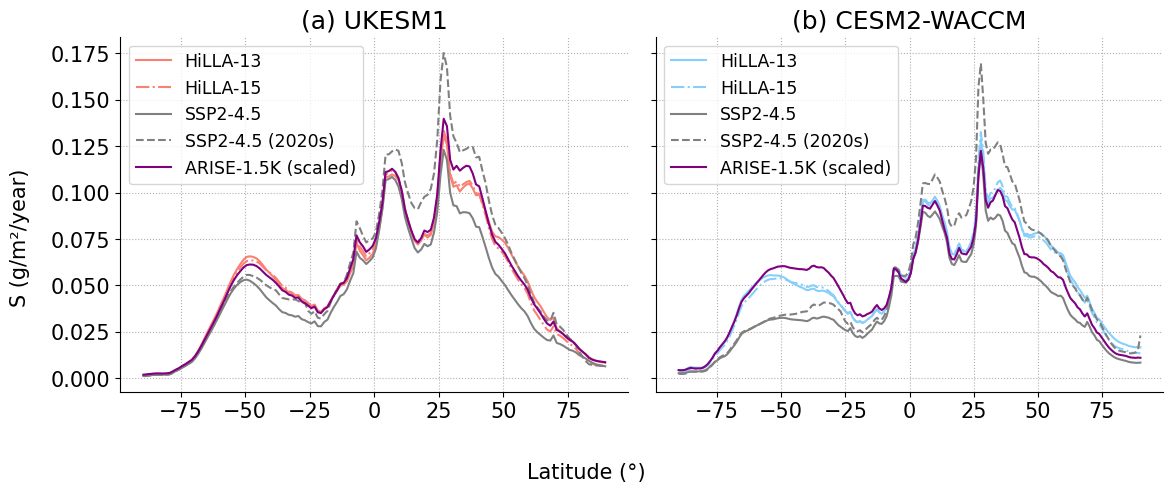

In [17]:
## now plot zonally (for all) and seasonally (for Hilla):

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 5), sharey='row')

labs = ['(a)', '(b)']
model_labs = {'UKESM':'UKESM1', 'CESM':'CESM2-WACCM'}

i=0
for model in ['UKESM', 'CESM']:
    
    ax = axs[i]
    for alt in ['13km', '15km']:
        H = HiLLA_data[model][alt].mean('lon')
        ax.plot(H.lat, H, c=model_colors[model], linestyle=lss[alt], label='HiLLA-{}'.format(alt[0:2]))
        
    S = SSP245_data[model].mean('lon')
    ax.plot(S.lat, S.so4, c=colours['ssp245'], label='SSP2-4.5')
    
    PD = SSP245_PD_data[model].mean('lon')
    ax.plot(PD.lat, PD.so4, c=colours['ssp245'], ls='--', label='SSP2-4.5 (2020s)')
    
    A = ARISE_data[model].mean('lon')
    ax.plot(A.lat, A, c=colours['ARISE'], label='ARISE-1.5K (scaled)')

    
    #if i == 0:
    #    ax.plot(ds_hist_UK.mean('lon').lat, ds_hist_UK.mean('lon').so4, c='firebrick', label='historical [1970-1990]')
    #if i==0:
    #    ax.legend(fontsize='small')
    ax.legend(fontsize='small')
    
    ax.grid(ls='dotted')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_title(labs[i]+' '+model_labs[model])
    i=i+1



## to do - add this to CESM (need to download the data first)

fig.supxlabel('Latitude (°)', fontsize='medium')
fig.supylabel('S (g/m²/year)', fontsize='medium')

plt.tight_layout()
plt.savefig('Figures/Zonal_mean_deposition.jpg', dpi=300)
plt.show()


Global value range for plotting: min=-0.88, max=0.69


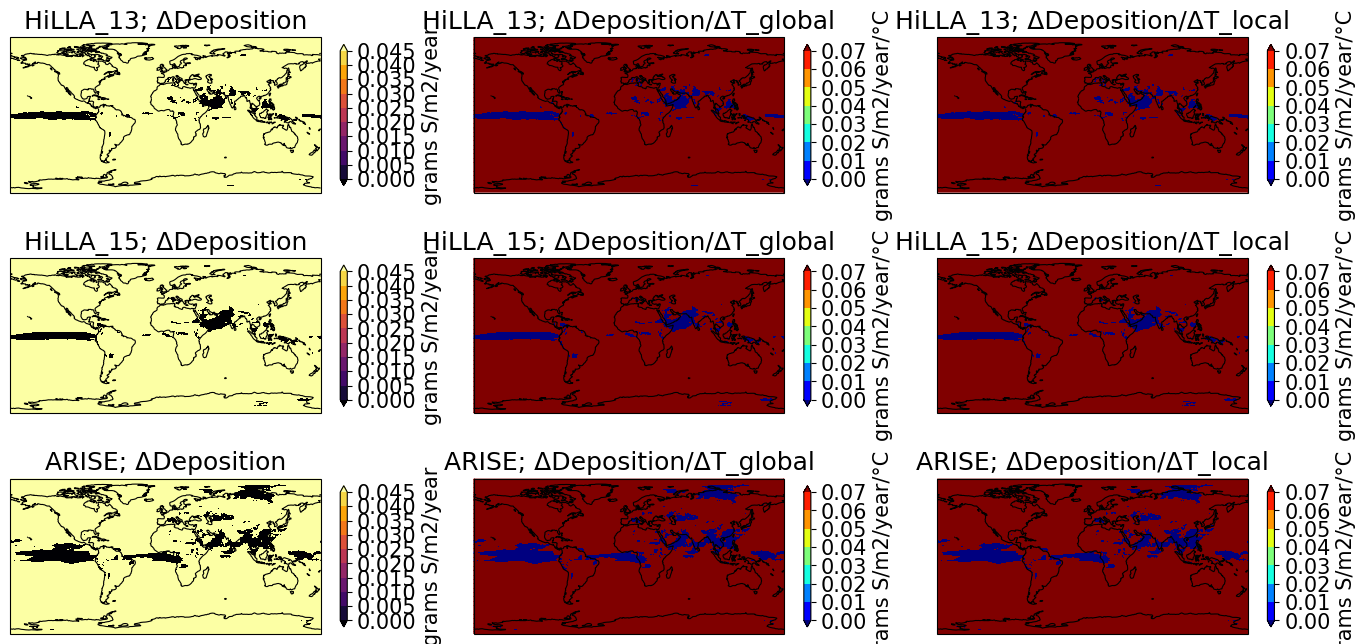

In [18]:
## now get total dry and total wet, and plot

das_to_plot = [HiLLA_13_total_delta_dep_CE, HiLLA_13_total_delta_dep_CE/cooling_13_gm_CE.item(), HiLLA_13_total_delta_dep_CE/cooling_13_CE.tas,
               HiLLA_15_total_delta_dep_CE, HiLLA_15_total_delta_dep_CE/cooling_15_gm_CE.item(), HiLLA_15_total_delta_dep_CE/cooling_15_CE.tas,
               arise_total_delta_dep_CE.so4, arise_total_delta_dep_CE.so4/arise_cooling_gm_CE.item(), arise_total_delta_dep_CE.so4/arise_cooling_CE.tas]


titles = ['HiLLA_13; ΔDeposition', 'HiLLA_13; ΔDeposition/ΔT_global', 'HiLLA_13; ΔDeposition/ΔT_local',
          'HiLLA_15; ΔDeposition', 'HiLLA_15; ΔDeposition/ΔT_global', 'HiLLA_15; ΔDeposition/ΔT_local',
          'ARISE; ΔDeposition', 'ARISE; ΔDeposition/ΔT_global', 'ARISE; ΔDeposition/ΔT_local']
          
labels = ['grams S/m2/year', 'grams S/m2/year/°C', 'grams S/m2/year/°C',
          'grams S/m2/year', 'grams S/m2/year/°C', 'grams S/m2/year/°C',
          'grams S/m2/year', 'grams S/m2/year/°C', 'grams S/m2/year/°C']

cmaps = ['inferno', 'jet', 'jet',
         'inferno', 'jet', 'jet',
         'inferno', 'jet', 'jet']

levelss = [np.arange(0, 0.05, 0.005), np.arange(0, 0.07, 0.01), np.arange(0, 0.07, 0.01),
           np.arange(0, 0.05, 0.005), np.arange(0, 0.07, 0.01), np.arange(0, 0.07, 0.01),
           np.arange(0, 0.05, 0.005), np.arange(0, 0.07, 0.01), np.arange(0, 0.07, 0.01)]

all_values = []
for da in das_to_plot:
    all_values.append(da.values.flatten())
global_vmin = np.min([np.min(vals) for vals in all_values])
global_vmax = np.max([np.max(vals) for vals in all_values])
print(f"\nGlobal value range for plotting: min={global_vmin:.2f}, max={global_vmax:.2f}")


fig, axes = plt.subplots(
    nrows=3, ncols=3,
    figsize=(14, 7), 
    subplot_kw={'projection': ccrs.PlateCarree()}
)


axes_flat = axes.flatten()

i=0
for ax in axes_flat:
    ax.set_global() 
    ax.coastlines(linewidth=0.8, color='black')
    data = das_to_plot[i]*unit_conversion
    plot = data.plot.pcolormesh(
            ax=ax,
            x='lon',
            y='lat',
            transform=ccrs.PlateCarree(),
            cmap=cmaps[i],
            cbar_kwargs={'shrink': 0.7, 'label': labels[i]},
            levels = levelss[i],
            extend='both',
            #vmin=0, 
            #vmax=global_vmax, 
            add_colorbar=True,
            add_labels=False 
        )
    ax.set_title(titles[i])
    i=i+1

plt.tight_layout()
plt.savefig('Figures/Deposition_HiLLA_overview_CESM.jpg', dpi=350, bbox_inches='tight')

In [19]:
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [20]:
import matplotlib
matplotlib.rcParams.update({'font.size': 14})

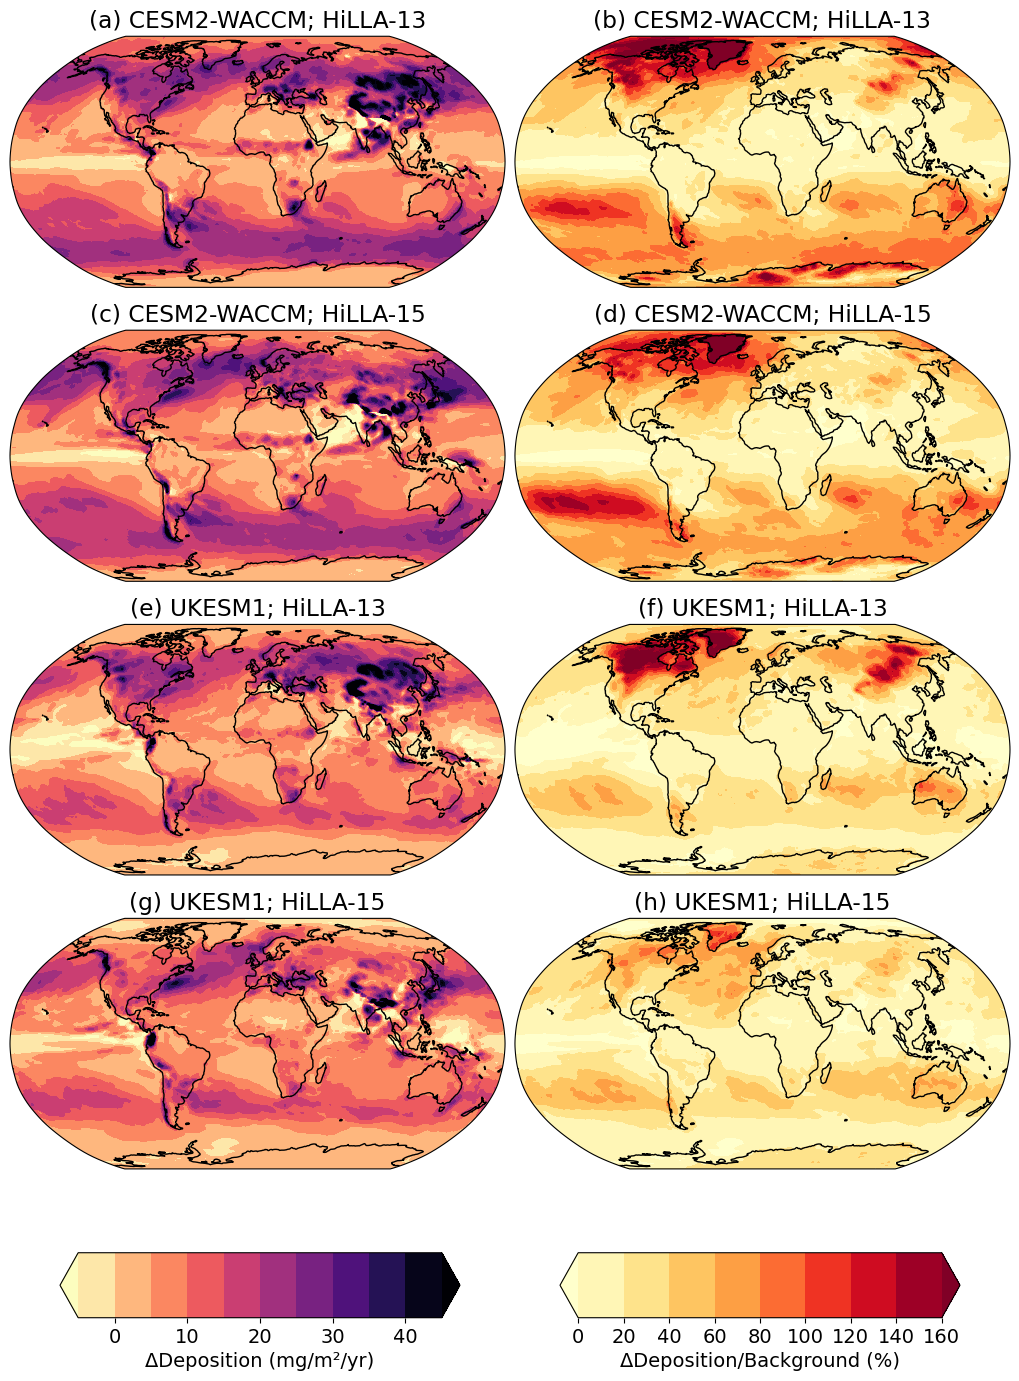

In [24]:

cols = 'viridis'
#clevs=np.arange(0,5.5E-5,0.5E-5) 

fig, axs = plt.subplots(nrows=4,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(10,13))

titles = ['(a) CESM2-WACCM; HiLLA-13', '(b) CESM2-WACCM; HiLLA-13',
          '(c) CESM2-WACCM; HiLLA-15', '(d) CESM2-WACCM; HiLLA-15', 
          '(e) UKESM1; HiLLA-13', '(f) UKESM1; HiLLA-13',
          '(g) UKESM1; HiLLA-15', '(h) UKESM1; HiLLA-15', 
         ]

to_plot = [1000*HiLLA_13_total_delta_dep_CE, 100*HiLLA_13_total_delta_dep_CE/ds_ssp245_CE.so4,
           1000*HiLLA_15_total_delta_dep_CE, 100*HiLLA_15_total_delta_dep_CE/ds_ssp245_CE.so4,
           1000*HiLLA_13_total_delta_dep_UK,  100*HiLLA_13_total_delta_dep_UK/ds_ssp245_UK.so4,
           1000*HiLLA_15_total_delta_dep_UK, 100*HiLLA_15_total_delta_dep_UK/ds_ssp245_UK.so4
          ]
cmap1, cmap2 = 'magma_r', 'YlOrRd'
cmaps = [cmap1, cmap2, 
         cmap1, cmap2,
         cmap1, cmap2,
         cmap1, cmap2]

levelss = [np.arange(-5, 50, 5), np.arange(0, 175, 20),
          np.arange(-5, 50, 5), np.arange(0, 175, 20),
          np.arange(-5, 50, 5), np.arange(0, 175, 20),
          np.arange(-5, 50, 5), np.arange(0, 175, 20)]

i=0
for ax in axs.flatten():
    ax.set_title(titles[i])
    d = to_plot[i]
    data,lons=add_cyclic_point(d,coord=d['lon'])
    if i in [0, 2]:
        cs1=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    else: 
        cs2=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    ax.coastlines()
    i=i+1

plt.tight_layout()

# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0.1, top=1, left=0, right=1,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax1 = fig.add_axes([0.05, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs1, cax=cbar_ax1,orientation='horizontal')
cbar.set_label('ΔDeposition (mg/m²/yr)', rotation=0)
cbar.ax.yaxis.label.set_va('center')


# Add a colorbar axis at the bottom of the graph
cbar_ax2 = fig.add_axes([0.55, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs2, cax=cbar_ax2,orientation='horizontal')
cbar.set_label('ΔDeposition/Background (%)', rotation=0)
cbar.ax.yaxis.label.set_va('center')
#plt.tight_layout()


plt.savefig('Figures/spatial_deposition_both_main.jpg', dpi=300, bbox_inches='tight')

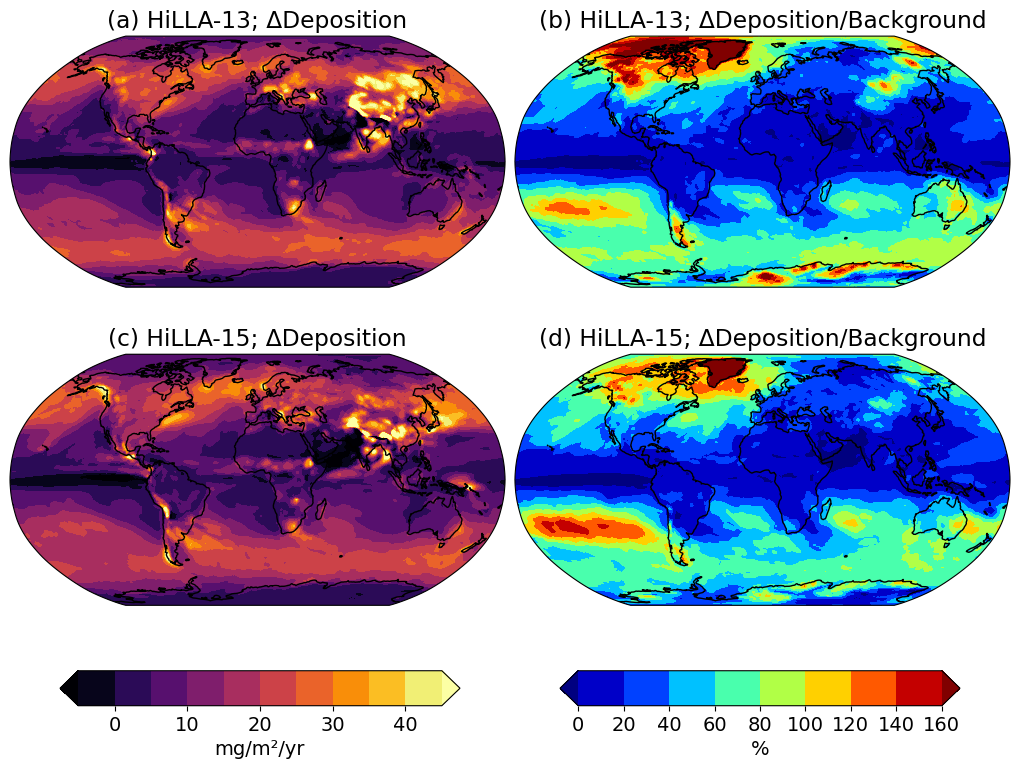

In [22]:

cols = 'viridis'
#clevs=np.arange(0,5.5E-5,0.5E-5) 

fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(10,7))

titles = ['(a) HiLLA-13; ΔDeposition', 
          '(b) HiLLA-13; ΔDeposition/Background', 
          '(c) HiLLA-15; ΔDeposition', 
          '(d) HiLLA-15; ΔDeposition/Background']

to_plot = [1000*HiLLA_13_total_delta_dep_CE, 100*HiLLA_13_total_delta_dep_CE/ds_ssp245_CE.so4,
           1000*HiLLA_15_total_delta_dep_CE, 100*HiLLA_15_total_delta_dep_CE/ds_ssp245_CE.so4]


cmaps = ['inferno', 'jet',
         'inferno', 'jet']

levelss = [np.arange(-5, 50, 5), np.arange(0, 175, 20),
           np.arange(-5, 50, 5), np.arange(0, 175, 20)]


i=0
for ax in axs.flatten():
    ax.set_title(titles[i])
    d = to_plot[i]
    data,lons=add_cyclic_point(d,coord=d['lon'])
    if i in [0, 2]:
        cs1=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    else: 
        cs2=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    ax.coastlines()
    i=i+1

plt.tight_layout()

# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0.1, top=1, left=0, right=1,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax1 = fig.add_axes([0.05, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs1, cax=cbar_ax1,orientation='horizontal')
cbar.set_label('mg/m²/yr', rotation=0)
cbar.ax.yaxis.label.set_va('center')


# Add a colorbar axis at the bottom of the graph
cbar_ax2 = fig.add_axes([0.55, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs2, cax=cbar_ax2,orientation='horizontal')
cbar.set_label('%', rotation=0)
cbar.ax.yaxis.label.set_va('center')
#plt.tight_layout()


#
plt.savefig('Figures/spatial_deposition_CESM_main.jpg', dpi=300, bbox_inches='tight')

In [23]:
#HiLLA_13_total_delta_dep_UK
HiLLA_13_total_delta_dep_CE

<xarray.DataArray (lat: 192, lon: 288)> Size: 221kB
dask.array<add, shape=(192, 288), dtype=float32, chunksize=(192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8

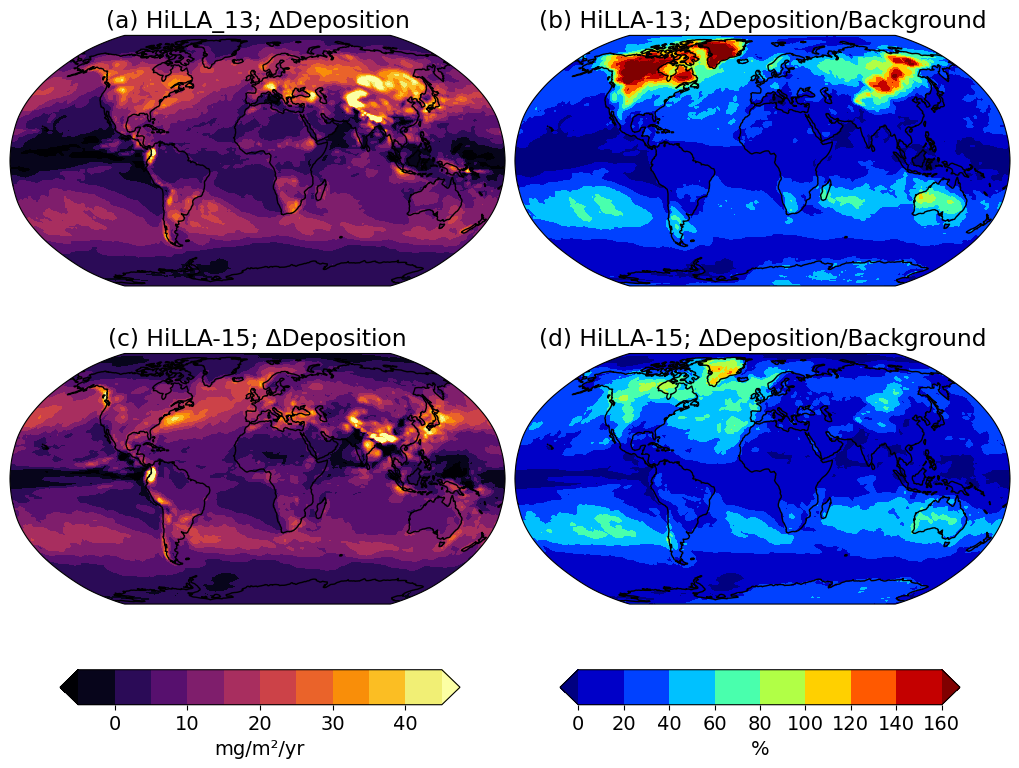

In [24]:

cols = 'viridis'
#clevs=np.arange(0,5.5E-5,0.5E-5) 

fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(10,7))

titles = ['(a) HiLLA_13; ΔDeposition', 
          '(b) HiLLA-13; ΔDeposition/Background', 
          '(c) HiLLA-15; ΔDeposition', 
          '(d) HiLLA-15; ΔDeposition/Background']

to_plot = [1000*HiLLA_13_total_delta_dep_UK, 100*HiLLA_13_total_delta_dep_UK/ds_ssp245_UK.so4,
           1000*HiLLA_15_total_delta_dep_UK, 100*HiLLA_15_total_delta_dep_UK/ds_ssp245_UK.so4]


cmaps = ['inferno', 'jet',
         'inferno', 'jet']

levelss = [np.arange(-5, 50, 5), np.arange(0, 175, 20),
           np.arange(-5, 50, 5), np.arange(0, 175, 20)]


i=0
for ax in axs.flatten():
    ax.set_title(titles[i])
    d = to_plot[i]
    data,lons=add_cyclic_point(d,coord=d['lon'])
    if i in [0, 2]:
        cs1=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    else: 
        cs2=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    ax.coastlines()
    i=i+1

plt.tight_layout()


# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0.1, top=1, left=0, right=1,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax1 = fig.add_axes([0.05, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs1, cax=cbar_ax1,orientation='horizontal')
cbar.set_label('mg/m²/yr', rotation=0)
cbar.ax.yaxis.label.set_va('center')


# Add a colorbar axis at the bottom of the graph
cbar_ax2 = fig.add_axes([0.55, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs2, cax=cbar_ax2,orientation='horizontal')
cbar.set_label('%', rotation=0)
cbar.ax.yaxis.label.set_va('center')

#fig.suptitle('UKESM1')
#plt.tight_layout()


#
plt.savefig('Figures/spatial_deposition_UKESM_main.jpg', dpi=300, bbox_inches='tight')

In [25]:
HiLLA_15_total_delta_dep_CE

<xarray.DataArray (lat: 192, lon: 288)> Size: 221kB
dask.array<add, shape=(192, 288), dtype=float32, chunksize=(192, 288), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8

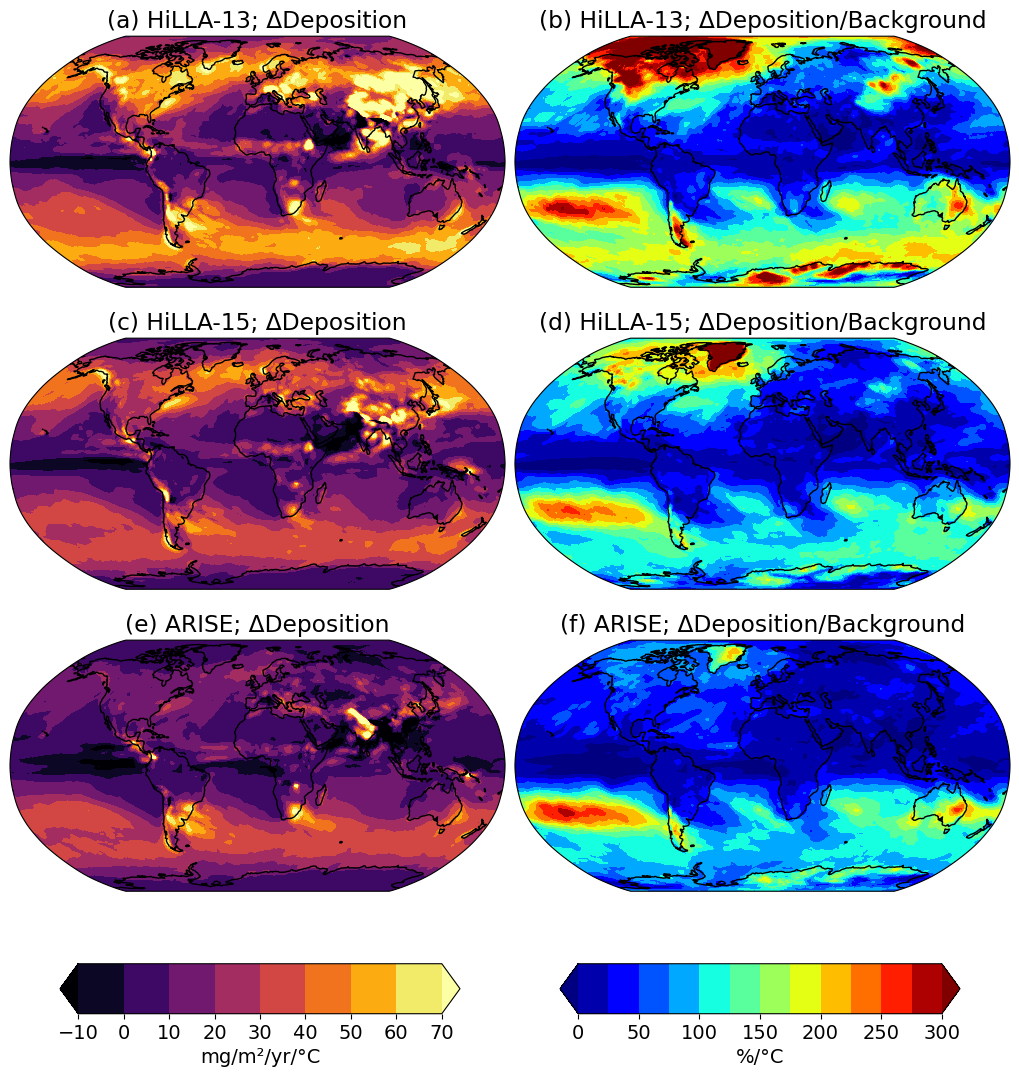

In [26]:

cols = 'viridis'
#clevs=np.arange(0,5.5E-5,0.5E-5) 

fig, axs = plt.subplots(nrows=3,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(10,10))

titles = ['(a) HiLLA-13; ΔDeposition', 
          '(b) HiLLA-13; ΔDeposition/Background', 
          '(c) HiLLA-15; ΔDeposition', 
          '(d) HiLLA-15; ΔDeposition/Background',
          '(e) ARISE; ΔDeposition',
          '(f) ARISE; ΔDeposition/Background']

to_plot = [1000*HiLLA_13_total_delta_dep_CE/cooling_13_gm_CE.item(), 100*HiLLA_13_total_delta_dep_CE/ds_ssp245_CE.so4/cooling_13_gm_CE.item(),
           1000*HiLLA_15_total_delta_dep_CE/cooling_15_gm_CE.item(), 100*HiLLA_15_total_delta_dep_CE/ds_ssp245_CE.so4/cooling_15_gm_CE.item(),
           1000*arise_total_delta_dep_CE.so4/arise_cooling_gm_CE.item(), 100*arise_total_delta_dep_CE.so4/ds_ssp245_CE.so4/arise_cooling_gm_CE.item()]


cmaps = ['inferno', 'jet',
         'inferno', 'jet',
         'inferno', 'jet']

levelss = [np.arange(-10, 80, 10), np.arange(0, 310, 25),
           np.arange(-10, 80, 10), np.arange(0, 310, 25),
           np.arange(-10, 80, 10), np.arange(0, 310, 25)]


i=0
for ax in axs.flatten():
    ax.set_title(titles[i])
    d = to_plot[i]
    data,lons=add_cyclic_point(d,coord=d['lon'])
    if i in [0, 2]:
        cs1=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    else: 
        cs2=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    ax.coastlines()
    i=i+1

plt.tight_layout()


# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0.1, top=1, left=0, right=1,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax1 = fig.add_axes([0.05, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs1, cax=cbar_ax1,orientation='horizontal')
cbar.set_label('mg/m²/yr/°C', rotation=0)
cbar.ax.yaxis.label.set_va('center')


# Add a colorbar axis at the bottom of the graph
cbar_ax2 = fig.add_axes([0.55, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs2, cax=cbar_ax2,orientation='horizontal')
cbar.set_label('%/°C', rotation=0)
cbar.ax.yaxis.label.set_va('center')

#plt.tight_layout()


#
plt.savefig('Figures/spatial_deposition_CESM_perdegCGlobal.jpg', dpi=300, bbox_inches='tight')

In [27]:
arise_total_delta_dep_UK

<xarray.Dataset> Size: 113kB
Dimensions:  (lat: 144, lon: 192)
Coordinates:
  * lat      (lat) float64 1kB -89.38 -88.12 -86.88 -85.62 ... 86.88 88.12 89.38
  * lon      (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
Data variables:
    so4      (lat, lon) float32 111kB dask.array<chunksize=(144, 192), meta=np.ndarray>

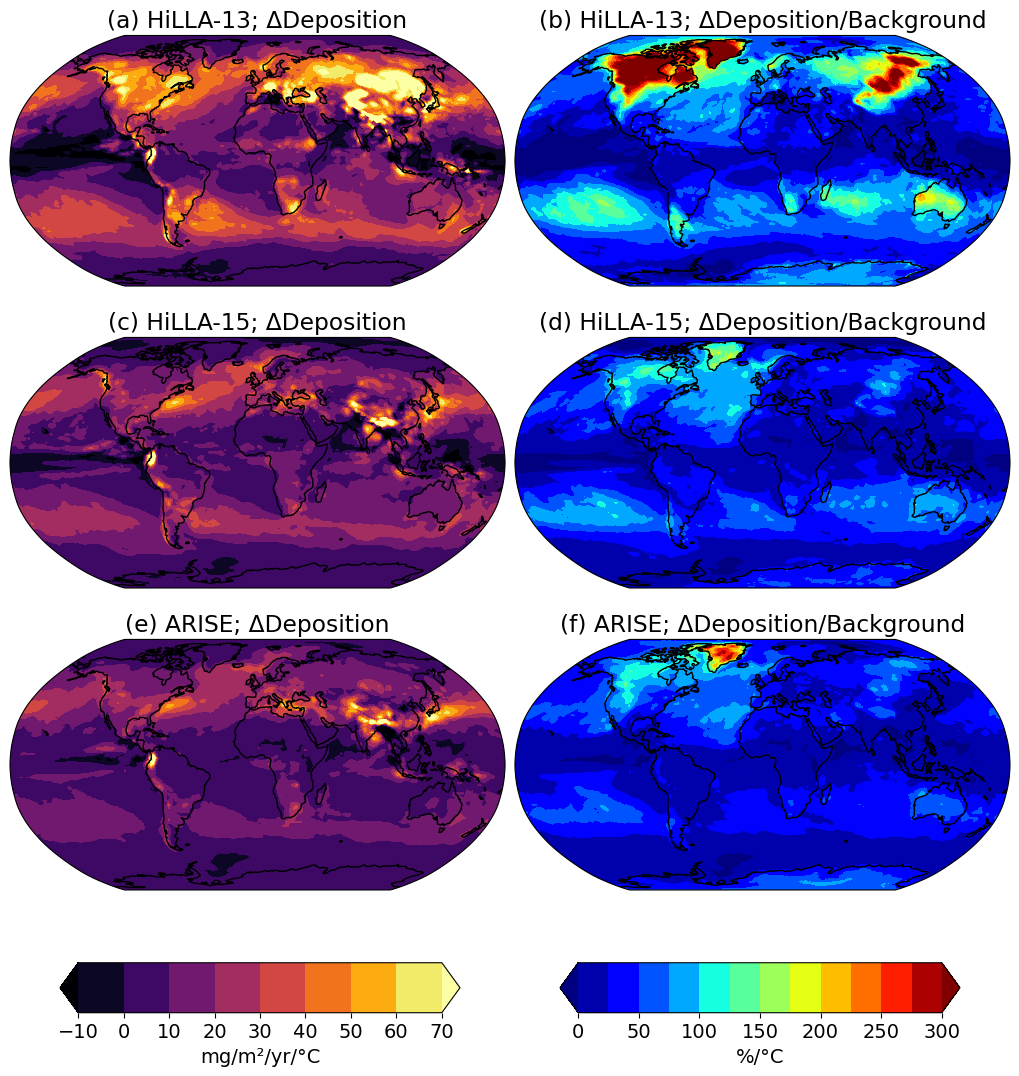

In [28]:

cols = 'viridis'
#clevs=np.arange(0,5.5E-5,0.5E-5) 

fig, axs = plt.subplots(nrows=3,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(10,10))

titles = ['(a) HiLLA-13; ΔDeposition', 
          '(b) HiLLA-13; ΔDeposition/Background', 
          '(c) HiLLA-15; ΔDeposition', 
          '(d) HiLLA-15; ΔDeposition/Background',
          '(e) ARISE; ΔDeposition',
          '(f) ARISE; ΔDeposition/Background']

to_plot = [1000*HiLLA_13_total_delta_dep_UK/cooling_13_gm_UK.item(), 100*HiLLA_13_total_delta_dep_UK/ds_ssp245_UK.so4/cooling_13_gm_UK.item(),
           1000*HiLLA_15_total_delta_dep_UK/cooling_15_gm_UK.item(), 100*HiLLA_15_total_delta_dep_UK/ds_ssp245_UK.so4/cooling_15_gm_UK.item(),
           1000*arise_total_delta_dep_UK.so4/arise_cooling_gm_UK.item(), 100*arise_total_delta_dep_UK.so4/ds_ssp245_UK.so4/arise_cooling_gm_UK.item()]


cmaps = ['inferno', 'jet',
         'inferno', 'jet',
         'inferno', 'jet']

levelss = [np.arange(-10, 80, 10), np.arange(0, 310, 25),
           np.arange(-10, 80, 10), np.arange(0, 310, 25),
           np.arange(-10, 80, 10), np.arange(0, 310, 25)]


i=0
for ax in axs.flatten():
    ax.set_title(titles[i])
    d = to_plot[i]
    data,lons=add_cyclic_point(d,coord=d['lon'])
    if i in [0, 2]:
        cs1=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    else: 
        cs2=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    ax.coastlines()
    i=i+1

plt.tight_layout()


# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0.1, top=1, left=0, right=1,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax1 = fig.add_axes([0.05, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs1, cax=cbar_ax1,orientation='horizontal')
cbar.set_label('mg/m²/yr/°C', rotation=0)
cbar.ax.yaxis.label.set_va('center')


# Add a colorbar axis at the bottom of the graph
cbar_ax2 = fig.add_axes([0.55, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs2, cax=cbar_ax2,orientation='horizontal')
cbar.set_label('%/°C', rotation=0)
cbar.ax.yaxis.label.set_va('center')

#plt.tight_layout()


#
plt.savefig('Figures/spatial_deposition_UKESM_perdegCGlobal.jpg', dpi=300, bbox_inches='tight')

In [ ]:

cols = 'viridis'
#clevs=np.arange(0,5.5E-5,0.5E-5) 

fig, axs = plt.subplots(nrows=3,ncols=2,
                        subplot_kw={'projection': ccrs.Robinson()},
                        figsize=(10,10))

titles = ['(a) HiLLA-13; ΔDeposition', 
          '(b) HiLLA-13; ΔDeposition/Background', 
          '(c) HiLLA-15; ΔDeposition', 
          '(d) HiLLA-15; ΔDeposition/Background',
          '(e) ARISE; ΔDeposition',
          '(f) ARISE; ΔDeposition/Background']

to_plot = [1000*unit_conversion*(HiLLA_13_total_delta_dep/cooling_13.tas), 100*(HiLLA_13_total_delta_dep/cooling_13.tas)/ds_ssp245_total.so4,
           1000*unit_conversion*(HiLLA_15_total_delta_dep/cooling_15.tas), 100*(HiLLA_15_total_delta_dep/cooling_15.tas)/ds_ssp245_total.so4,
           1000*unit_conversion*(arise_total_delta_dep/arise_cooling.tas), 100*(arise_total_delta_dep/cooling_15.tas)/ds_ssp245_total.so4]


cmaps = ['inferno', 'jet',
         'inferno', 'jet',
         'inferno', 'jet']

levelss = [np.arange(-10, 80, 10), np.arange(0, 310, 25),
           np.arange(-10, 80, 10), np.arange(0, 310, 25),
           np.arange(-10, 80, 10), np.arange(0, 310, 25)]


i=0
for ax in axs.flatten():
    ax.set_title(titles[i])
    d = to_plot[i]
    data,lons=add_cyclic_point(d,coord=d['lon'])
    if i in [0, 2]:
        cs1=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    else: 
        cs2=ax.contourf(lons,d['lat'],data,
                       levels=levelss[i],
                       transform = ccrs.PlateCarree(),
                       cmap=cmaps[i],
                       extend='both')
    ax.coastlines()
    i=i+1

plt.tight_layout()


# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(bottom=0.1, top=1, left=0, right=1,
                    wspace=0.02, hspace=0.02)

# Add a colorbar axis at the bottom of the graph
cbar_ax1 = fig.add_axes([0.05, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs1, cax=cbar_ax1,orientation='horizontal')
cbar.set_label('mg/m²/yr/°C', rotation=0)
cbar.ax.yaxis.label.set_va('center')


# Add a colorbar axis at the bottom of the graph
cbar_ax2 = fig.add_axes([0.55, 0, 0.4, 0.05])
# Draw the colorbar
cbar=fig.colorbar(cs2, cax=cbar_ax2,orientation='horizontal')
cbar.set_label('%/°C', rotation=0)
cbar.ax.yaxis.label.set_va('center')

#plt.tight_layout()


#
plt.savefig('Figures/spatial_deposition_CESM_perdegCLocal.jpg'.format(var), dpi=300, bbox_inches='tight')